# Практическая работа 8 (Тест)

**Тема**: Корреляционно-регрессионный анализ

### Настройка окружения

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Часть 1

Набор данных [ScrabbleGames.csv](ScrabbleGames.csv) содержит сведения о результатах турниров игры в скрэббл.

*Описание переменных:*

- **gameid** — номер игры в скрэббл
- **tourneyid** — номер турнира
- **tie** — игра закончилась вничью
- **winnerid** — порядковый номер победителя
- **winnername** — имя победителя
- **winnerscore** — набранные победителем очки
- **winneroldrating** — рейтинг победителя до игры
- **winnernewrating** — рейтинг победителя после игры
- **winnerpos** — место победителя в турнире
- **loserid** — порядковый номер проигравшего
- **loserscore** — набранные проигравшем очки
- **loseroldrating** — рейтинг проигравшего до игры
- **losernewrating** — рейтинг проигравшего после игры
- **loserpos** — место проигравшего в турнире
- **round** — раунд турнира, в котором проходила игра
- **division** — дивизион турнира, в котором проходила игра
- **date** — дата игры
- **lexicon** — набор слов, который использовался в игре (международный - 1; характерный для Северной Америки - 0)
- **year** — год

In [2]:
games = pd.read_csv("ScrabbleGames.csv", parse_dates=["date"], index_col="gameid")
games.head()

,tourneyid,tie,winnerid,winnername,winnerscore,winneroldrating,winnernewrating,winnerpos,loserid,losername,loserscore,loseroldrating,losernewrating,loserpos,round,division,date,lexicon,year
gameid,,,,,,,,,,,,,,,,,,,
451519,1590,0,38,Matt Laufer,0,1892,1877,5,608,Pam Grazette,0,1712,1692,14,1,1,1994-03-11,0,1994
451520,1590,0,38,Matt Laufer,0,1892,1877,5,82,Sally Ricketts,0,1390,1347,36,3,1,1994-03-11,0,1994
451521,1590,0,38,Matt Laufer,0,1892,1877,5,4001,James Guillot,0,1712,1700,22,5,1,1994-03-11,0,1994
451522,1590,0,38,Matt Laufer,0,1892,1877,5,5676,Rhoda Squires,0,1642,1591,29,8,1,1994-03-11,0,1994
451523,1590,0,38,Matt Laufer,0,1892,1877,5,4001,James Guillot,0,1712,1700,22,9,1,1994-03-11,0,1994


### Вопрос 1

Сгруппируйте датафрейм по переменной **tourneyid**, затем определите тип взаимосвязи между средними значениями переменных **winnerscore** и **winnernewrating**.

In [3]:
games_by_tourney = games.groupby("tourneyid")
mean_players_stats = games_by_tourney[["winnerscore", "winnernewrating"]].mean()

round(mean_players_stats["winnerscore"].corr(mean_players_stats["winnernewrating"]), 2)

np.float64(-0.6)

*Ответ:* Связь заметная обратная

### Вопрос 2

Укажите, верно ли следующее утверждение: очки, набранные победителем, напрямую и сильно зависят от очков, набранных проигравшим. Сгруппируйте датафрейм по переменной **tourneyid** и посмотрите на средние значения интересующих нас переменных.

In [4]:
mean_scores = games_by_tourney[["winnerscore", "loserscore"]].mean()

round(mean_scores["winnerscore"].corr(mean_scores["loserscore"]), 2)

np.float64(1.0)

*Ответ:* Верно

### Вопрос 3

Между какими переменными можно найти интерпретируемый коэффициент корреляции?

*Варианты ответа:*

1. **loserid** и **loserpos**

2. **winnerid** и **loserid**

3. **gameid** и **tie**

4. **winnerpos** и **loserpos**

*Ответ:* 1

### Вопрос 4

Что можно сказать по графику о взаимосвязи переменных **winnerscore** и **winnerpos**?

*Варианты ответа:*

1. Связь умеренная прямая

2. Связи практически нет

3. Связь сильная обратная

4. Связь сильная прямая

*Ответ*: 2

### Вопрос 5

Выберите только пятые раунды турнира, сгруппируйте датафрейм по переменной **tourneyid**, затем рассчитайте коэффициент корреляции между средними значениями переменных **winneroldrating** и **winnernewrating**. Ответ округлите до двух знаков после запятой (например, 0,29); если связь обратная, не забудьте указать минус перед числом.

In [5]:
fifth_round_games = games[games["round"] == 5]

games_by_tourney_5th = fifth_round_games.groupby("tourneyid")

mean_winner_ratings = games_by_tourney_5th[["winneroldrating", "winnernewrating"]].mean()

round(mean_winner_ratings["winneroldrating"].corr(mean_winner_ratings["winnernewrating"]), 2)

np.float64(0.51)

### Вопрос 6

Укажите, верно ли следующее утверждение: переменная **tie** не влияет на характер взаимосвязи между переменными **winnernewrating** и **losernewrating**. Сгруппируйте датафрейм по переменной **tourneyid**, затем рассчитайте коэффициент корреляции между средними значениями указанных переменных.

In [6]:
games_by_tourney_and_tie = games.groupby(["tourneyid", "tie"])

mean_new_ratings = games_by_tourney_and_tie[["winnernewrating", "losernewrating"]].mean().reset_index()

is_tie = mean_new_ratings["tie"] == 1
tie_games = mean_new_ratings[is_tie]
no_tie_games = mean_new_ratings[~is_tie]

r_tie = round(tie_games["winnernewrating"].corr(tie_games["losernewrating"]), 2)
r_no_tie = round(no_tie_games["winnernewrating"].corr(no_tie_games["losernewrating"]), 2)

print(f"При tie = 0 коэффициент корреляции между winnernewrating и losernewrating: {r_no_tie}")
print(f"При tie = 1 коэффициент корреляции между winnernewrating и losernewrating: {r_tie}")

При tie = 0 коэффициент корреляции между winnernewrating и losernewrating: 0.98
При tie = 1 коэффициент корреляции между winnernewrating и losernewrating: 0.92


*Ответ:* Верно

### Вопрос 7

Укажите, верно ли следующее утверждение: характер взаимосвязи (прямая или обратная) между средними значениями переменных **winnerscore** и **winneroldrating** для победителя по имени *Lester Schonbrun* не отличается для такого же показателя для победителя по имени *Paul Avrin*. Сгруппируйте датафрейм по переменной **tourneyid**, затем рассчитайте коэффициент корреляции между средними значениями указанных переменных.

In [7]:
def get_corr_by_player(games: pd.DataFrame, player_name: str) -> float:
  player_games = games[games["winnername"] == player_name]
  stats_by_tourney = player_games.groupby("tourneyid")[["winnerscore", "winneroldrating"]].mean()
  return stats_by_tourney["winnerscore"].corr(stats_by_tourney["winneroldrating"])


r_lester = get_corr_by_player(games, "Lester Schonbrun")
r_paul = get_corr_by_player(games, "Paul Avrin")

print(f"Корреляция между winnerscore и winneroldrating:")
print(f"  - Lester Schonbrun: {r_lester:.2f}")
print(f"  - Paul Avrin: {r_paul:.2f}")

Корреляция между winnerscore и winneroldrating:
  - Lester Schonbrun: 0.05
  - Paul Avrin: 0.10


*Ответ:* Верно

### Вопрос 8

Выберите данные только за 2951 турнир (переменная **tourneyid**). Рассчитайте коэффициент корреляции между переменными **winnerscore** и **loserscore**. Ответ округлите до двух знаков после запятой; если связь обратная, не забудьте указать минус перед числом.

In [8]:
games_2951_tourney = games[games["tourneyid"] == 2951]

round(games_2951_tourney["winnerscore"].corr(games_2951_tourney["loserscore"]), 2)

np.float64(0.99)

## Часть 2

Набор данных [Bikes.csv](Bikes.csv) содержит сведения о работе велопроката.

*Описание переменных:*

- **Date** - день/месяц/год (с 1 декабря 2017 года по 30 ноября 2018 года)
- **Hour** - час (от 0 до 24)
- **Temperature** - температура в градусах Цельсия
- **Humidity** - процент влажности
- **Wind speed** - скорость ветра м/сек
- **Rainfall** - осадки в виде дождя, мм
- **Snowfall** - осадки в виде снега, мм
- **Seasons** - сезон (Winter, Spring, Summer, Autumn)
- **Holiday** - рабочий или праздничный день (Holiday/No holiday)
- **Function Day** - рабочий или нерабочий день велопроката (Yes/No)
- **Rental Count** - количество велосипедов, взятых в аренду в этот час
- **Normal Humidity** - была ли влажность нормальной
- **Temperature Category** - категория температуры (Freezing (заморозки), Chilly (прохладно), Nice (идеальная), Hot (жарко))
- **Good Weather** - была ли погода хорошей.

In [9]:
bikes = pd.read_csv("Bikes.csv", parse_dates=["Date"])
bikes.head()

,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Rental Count,Normal Humidity,Temperature Category,Good Weather
0,2017-12-01,0,-5.2,37,2.2,0.0,0.0,Winter,0,True,257,0,Freezing,0
1,2017-12-01,1,-5.5,38,0.8,0.0,0.0,Winter,0,True,219,0,Freezing,0
2,2017-12-01,2,-6.0,39,1.0,0.0,0.0,Winter,0,True,162,0,Freezing,0
3,2017-12-01,3,-6.2,40,0.9,0.0,0.0,Winter,0,True,148,1,Freezing,0
4,2017-12-01,4,-6.0,36,2.3,0.0,0.0,Winter,0,True,97,0,Freezing,0


### Вопрос 1

С использованием группировки определите среднюю температуру и суммарное кол-во аренд по неделям. Сохраните результат в переменную *bikes_week*. Выберите суммарное кол-во аренд в 1 неделю.

С использованием группировки определите среднюю температуру и суммарное кол-во аренд по неделям. Сохраните результат в переменную *bikes_week*. Выберите суммарное кол-во аренд во 2 неделю.

In [10]:
bikes_week = bikes.groupby(bikes["Date"].dt.isocalendar().week).agg({
  "Temperature": "mean",
  "Rental Count": "sum"
}).rename_axis("Week")

bikes_week.loc[2, "Rental Count"]

np.int64(30871)

### Вопрос 2

Проведите первичный визуальный анализ данных и определите возможное наличие зависимости между средней температурой и суммарным числом аренд велосипедов в неделю. Выберите получившуюся диаграмму разброса.

<Axes: xlabel='Temperature', ylabel='Rental Count'>

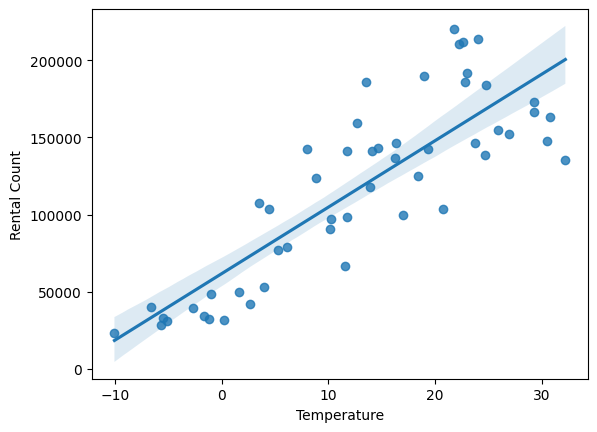

In [11]:
sns.regplot(bikes_week, x="Temperature", y="Rental Count")

### Вопрос 3

В датафрейме *bikes_week* отберите данные для последних 5 недель. Вычислите значение коэффициента корреляции между средней температурой и суммарным числом аренд велосипедов. В ответе укажите число, округленное до 2 знаков после запятой.

In [12]:
bikes_last_5_weeks = bikes_week.tail(5)

round(bikes_last_5_weeks["Temperature"].corr(bikes_last_5_weeks["Rental Count"]), 2)

np.float64(0.66)

### Вопрос 4

Вычислите значение коэффициента корреляции между средней температурой и суммарным числом аренд велосипедов по данным всех недель. В ответе укажите число, округленное до 2 знаков после запятой.

In [13]:
round(bikes_week["Temperature"].corr(bikes_week["Rental Count"]), 2)

np.float64(0.85)

### Вопрос 5

Рассчитайте для каждой недели среднюю влажность и среднюю скорость ветра. С помощью метода `pd.concat()` объедините результаты с датафреймом *bikes_week*. Постройте матрицу корреляции и выберите характеристику, которая связана с общим числом аренд велосипедов умеренной корреляционной связью.

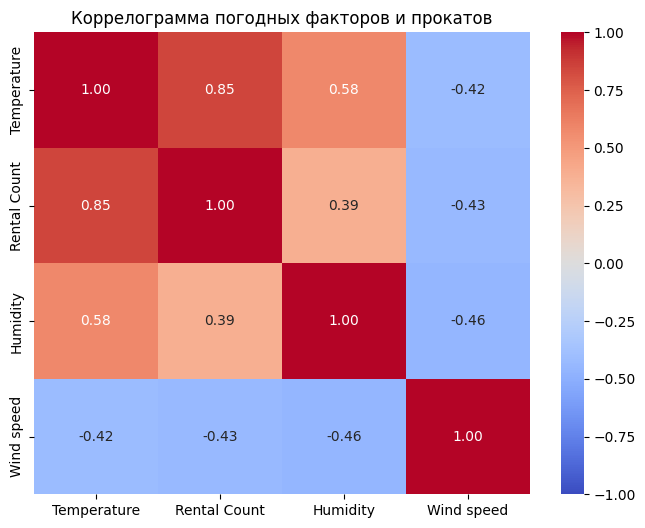

In [14]:
bikes_week2 = bikes.groupby(bikes["Date"].dt.isocalendar().week).agg({
  "Humidity": "mean",
  "Wind speed": "mean"
}).rename_axis("Week")

bikes_week = pd.concat([bikes_week, bikes_week2], axis=1)

plt.figure(figsize=(8, 6))
sns.heatmap(
  bikes_week.corr(),
  vmin=-1,
  vmax=1,
  annot=True,
  fmt=".2f",
  cmap="coolwarm",
)
plt.title("Коррелограмма погодных факторов и прокатов")
plt.show()

*Ответ: Wind speed*

## Часть 3

Продолжаем работать с агрегированным набором данных аренд велосипедов *bikes_week*, в котором для каждой недели мы определили среднюю температуру, среднюю влажность, среднюю скорость ветра и суммарное число аренд. На основе этих данных попробуем построить различные модели линейной регрессии, позволяющие предсказать общее число аренд велосипедов в неделю.

### Вопрос 1

Постройте парные графики рассеяния. Между суммарным кол-вом арендованных велосипедов и другими переменными есть линейные зависимости.

*Ответ:* Верно

### Вопрос 2

Постройте модель линейной регрессии, которая будет на основе средненедельной температуры предсказывать общее число аренд велосипедов в неделю.

In [15]:
X = bikes_week[["Temperature"]]
y = bikes_week["Rental Count"]

temp_regressor = LinearRegression()
temp_regressor.fit(X, y)

intercept = temp_regressor.intercept_
slope = temp_regressor.coef_[0]

print(f"Уравнение линейной регрессии: Rental Count = {intercept:.2f} + {slope:.2f} * Temperature")

Уравнение линейной регрессии: Rental Count = 61741.70 + 4309.32 * Temperature


### Вопрос 3

Коэффициент детерминации получившейся модели, округленный до 2 знаков после запятой.

In [16]:
predicted_y = temp_regressor.predict(X)

round(metrics.r2_score(y, predicted_y), 2)

0.72

### Вопрос 4
Укажите предсказанное моделью кол-во арендованных велосипедов при средненедельной температуре 5 градусов. Ответ округлите до целого.

In [17]:
X_test = pd.DataFrame({"Temperature": [5]})

round(temp_regressor.predict(X_test)[0])

83288

### Вопрос 5

Постройте модель линейной регрессии, которая будет на основе средненедельных температуры, влажности и скорости ветра предсказывать общее число аренд велосипедов в неделю. В ответе укажите значение коэффициента при скорости ветра, округленное до 2 знаков после запятой.

In [18]:
X = bikes_week[["Temperature", "Humidity", "Wind speed"]]
y = bikes_week["Rental Count"]

weather_regressor = LinearRegression()
weather_regressor.fit(X, y)

round(weather_regressor.coef_[2], 2)

np.float64(-26750.6)

### Вопрос 6

Укажите предсказанное моделью кол-во арендованных велосипедов при средненедельных температуре 8 градусов, влажности 58%, скорости ветра 3 м/с. Ответ округлите до целого.

In [19]:
X_test = pd.DataFrame({
  "Temperature": [8],
  "Humidity": [58],
  "Wind speed": [3]
})

round(weather_regressor.predict(X_test)[0])

60961

### Вопрос 7

Среднеквадратичная ошибка в единицах исследуемой переменной (*RMSE*) получившейся модели, округленная до 2 знаков после запятой.

In [20]:
predicted_y = weather_regressor.predict(X)

rmse = round(metrics.root_mean_squared_error(y, predicted_y), 2)

rmse

28898.44

## Ошибки

- Вопрос 3 - неправильно
- Вопрос 6 - переменная tie **не влияет**
- Вопрос 13 - неправильно
- Вопрос 17 - неправильно

In [21]:
# Экспорт в html
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", __vsc_ipynb_file__.split("/")[-1]])

[NbConvertApp] Converting notebook practice8.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 440609 bytes to practice8.html


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'practice8.ipynb'], returncode=0)